In [1]:
!pip install prophet

from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import sqlite3
import pandas as pd

# Reconectar ao banco
conn = sqlite3.connect("lh_nautical.db")

# Verificar as tabelas
query = "SELECT name FROM sqlite_master WHERE type='table'"
print(pd.read_sql(query, conn))

            name
0         vendas
1       produtos
2       clientes
3         custos
4  base_completa


In [3]:
query = """
SELECT
    DATE(sale_date) AS ds,
    ROUND(SUM(total), 2) AS y

FROM base_completa
GROUP BY DATE(sale_date)
ORDER BY ds
"""

df_prophet = pd.read_sql(query, conn)
df_prophet["ds"] = pd.to_datetime(df_prophet["ds"])

print("Dados preparados!")
print(f"Total de dias: {len(df_prophet)}")
df_prophet.head()

Dados preparados!
Total de dias: 725


,ds,y
0,2023-01-01,4207939.25
1,2023-01-02,5102799.80
2,2023-01-03,8299127.05
3,2023-01-04,4707759.40
4,2023-01-05,5525706.90


In [ ]:
# Criar calendário completo
todos_os_dias = pd.date_range(
    start=df_prophet["ds"].min(),
    end=df_prophet["ds"].max(),
    freq="D"
)

# Identificar dias sem venda
dias_sem_venda = len(todos_os_dias) - len(df_prophet)
print(f"Total de dias no período: {len(todos_os_dias)}")
print(f"Dias com venda: {len(df_prophet)}")
print(f"Dias sem venda: {dias_sem_venda}")

# Preencher dias sem venda com 0
df_prophet = df_prophet.set_index("ds")
df_prophet = df_prophet.reindex(todos_os_dias, fill_value=0)
df_prophet = df_prophet.reset_index()
df_prophet.columns = ["ds", "y"]

print("Dias sem venda preenchidos com 0!")

Total de dias no período: 731
Dias com venda: 725
Dias sem venda: 6
✅ Dias sem venda preenchidos com 0!


In [ ]:
modelo = Prophet(
    yearly_seasonality=True,   # sazonalidade anual
    weekly_seasonality=True,   # sazonalidade semanal
    daily_seasonality=False,   # não precisa para dados diários
    seasonality_mode="multiplicative"  # melhor para dados de varejo
)

modelo.fit(df_prophet)
print("Modelo treinado!")

✅ Modelo treinado!


In [ ]:
# Prever os próximos 90 dias (3 meses)
futuro = modelo.make_future_dataframe(periods=90)
previsao = modelo.predict(futuro)

print("Previsão gerada!")
print("\nPróximos 30 dias:")
proximos_30 = previsao[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(90).head(90)
proximos_30.columns = ["Data", "Previsão", "Mínimo", "Máximo"]
proximos_30["Previsão"] = proximos_30["Previsão"].apply(lambda x: f"R$ {x:,.2f}")
proximos_30["Mínimo"] = proximos_30["Mínimo"].apply(lambda x: f"R$ {x:,.2f}")
proximos_30["Máximo"] = proximos_30["Máximo"].apply(lambda x: f"R$ {x:,.2f}")
print(proximos_30.to_string(index=False))

✅ Previsão gerada!

Próximos 30 dias:
      Data        Previsão          Mínimo          Máximo
2025-01-01 R$ 3,847,397.34 R$ 1,547,164.60 R$ 5,969,500.11
2025-01-02 R$ 3,875,683.32 R$ 1,592,268.46 R$ 6,211,755.84
2025-01-03 R$ 3,895,401.60 R$ 1,726,146.24 R$ 5,960,871.11
2025-01-04 R$ 3,821,409.35 R$ 1,536,396.23 R$ 6,123,727.28
2025-01-05 R$ 3,367,007.81 R$ 1,276,144.70 R$ 5,582,608.18
2025-01-06 R$ 3,439,375.90 R$ 1,317,158.90 R$ 5,686,430.01
2025-01-07 R$ 3,525,183.04 R$ 1,154,374.66 R$ 5,809,028.02
2025-01-08 R$ 3,367,579.29 R$ 1,009,424.90 R$ 5,515,507.03
2025-01-09 R$ 3,389,132.50 R$ 1,168,153.23 R$ 5,713,583.70
2025-01-10 R$ 3,410,936.61 R$ 1,252,037.91 R$ 5,706,317.42
2025-01-11 R$ 3,347,876.36 R$ 1,156,574.74 R$ 5,775,980.07
2025-01-12 R$ 2,913,066.91   R$ 760,665.31 R$ 4,971,582.04
2025-01-13 R$ 3,013,369.05 R$ 1,015,181.53 R$ 5,279,918.99
2025-01-14 R$ 3,134,868.55 R$ 1,122,468.04 R$ 5,307,530.90
2025-01-15 R$ 3,019,972.67   R$ 846,033.37 R$ 5,115,645.79
2025-01-16 R$ 3,09

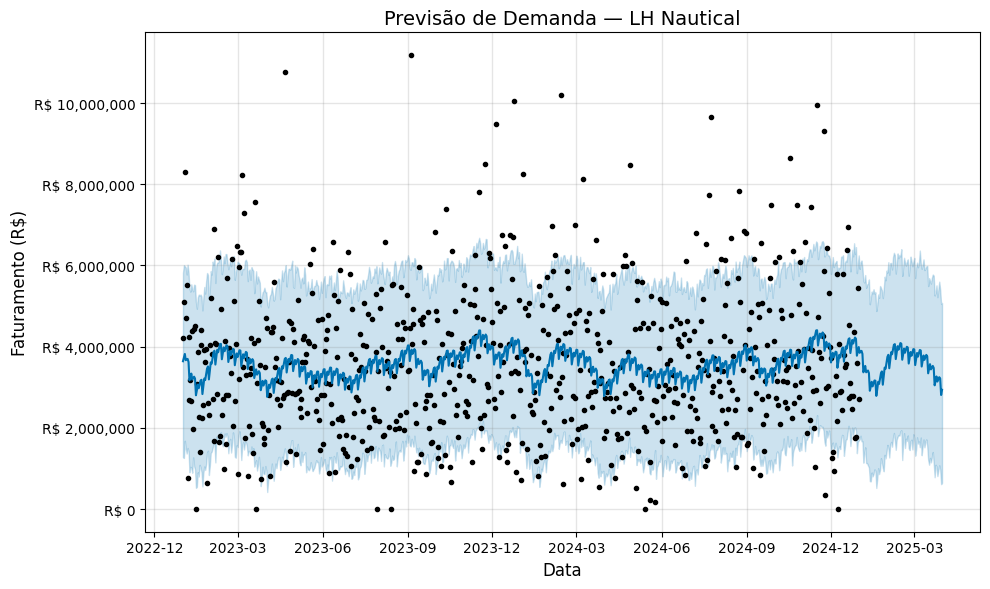

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Gerar o gráfico do Prophet
fig = modelo.plot(previsao)

# Pegar o eixo do gráfico
ax = fig.gca()

# Corrigir o eixo Y para formato R$
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}")
)

# Ajustar títulos
ax.set_title("Previsão de Demanda — LH Nautical", fontsize=14)
ax.set_xlabel("Data", fontsize=12)
ax.set_ylabel("Faturamento (R$)", fontsize=12)

plt.tight_layout()
plt.show()

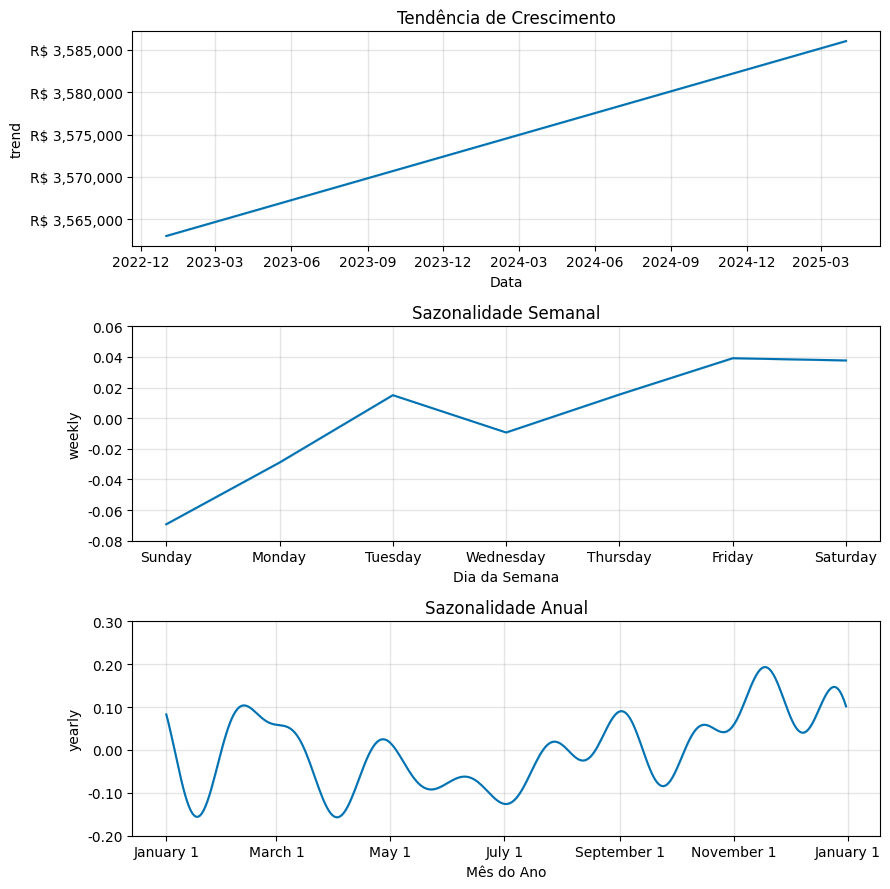

In [ ]:
fig2 = modelo.plot_components(previsao)

axes = fig2.get_axes()

# Gráfico 1 — Trend (esse sim tem R$)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}")
)
axes[0].set_title("Tendência de Crescimento")
axes[0].set_xlabel("Data")

# Gráfico 2 — Weekly (variação por dia da semana)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:,.2f}")
)
axes[1].set_title("Sazonalidade Semanal")
axes[1].set_xlabel("Dia da Semana")

# Gráfico 3 — Yearly (variação por época do ano)
axes[2].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:,.2f}")
)
axes[2].set_title("Sazonalidade Anual")
axes[2].set_xlabel("Mês do Ano")

plt.tight_layout()
plt.show()

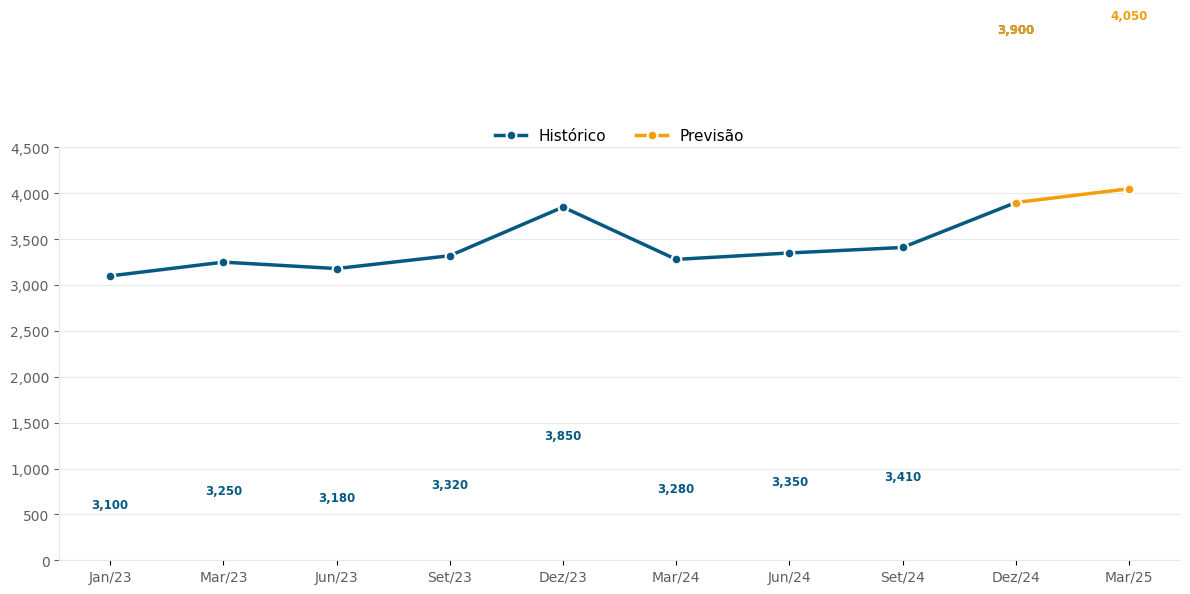

Gráfico salvo!


In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
# ── Títulos dos eixos ──────────────────────────────────
ax.set_title(
    "Previsão de Demanda — LH Nautical (2023–2025)",
    fontsize=14, fontweight="bold", color="#0A1628", pad=20
)

ax.set_xlabel(
    "Período",
    fontsize=11, color="#605E5C", labelpad=10
)

ax.set_ylabel(
    "Faturamento Médio (R$)",
    fontsize=11, color="#605E5C", labelpad=10
)
# ── Dados ──────────────────────────────────────────────
historico_datas = ["Jan/23","Mar/23","Jun/23","Set/23","Dez/23","Mar/24","Jun/24","Set/24","Dez/24"]
historico_vals  = [3100, 3250, 3180, 3320, 3850, 3280, 3350, 3410, 3900]
previsao_datas  = ["Dez/24", "Mar/25"]
previsao_vals   = [3900, 4050]

# ── Figura ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

# Grade suave
ax.yaxis.grid(True, color="#E8E8E8", linewidth=0.8, zorder=0)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# Linha histórico
ax.plot(
    historico_datas, historico_vals,
    color="#065A82", linewidth=2.5,
    marker="o", markersize=7,
    markerfacecolor="#065A82", markeredgecolor="white", markeredgewidth=1.5,
    label="Histórico", zorder=3
)

# Linha previsão
ax.plot(
    previsao_datas, previsao_vals,
    color="#F59E0B", linewidth=2.5,
    marker="o", markersize=7,
    markerfacecolor="#F59E0B", markeredgecolor="white", markeredgewidth=1.5,
    label="Previsão", zorder=3
)

# ── Rótulos nos pontos do histórico ───────────────────
todas_datas = historico_datas + ["Mar/25"]

for i, (data, val) in enumerate(zip(historico_datas, historico_vals)):
    # Ajuste vertical: pontos de pico sobem, outros descem
    offset_y = 120 if val == max(historico_vals) else -160
    ha = "center"

    ax.annotate(
        f"{val:,}",
        xy=(i, val),
        xytext=(0, offset_y),
        textcoords="offset points",
        ha=ha, va="bottom" if offset_y > 0 else "top",
        fontsize=8.5, color="#065A82", fontweight="bold",
        arrowprops=None
    )

# ── Rótulos nos pontos da previsão ────────────────────
# Índices da previsão no eixo X completo
idx_dez24 = todas_datas.index("Dez/24")
idx_mar25 = todas_datas.index("Mar/25")

for idx, val in zip([idx_dez24, idx_mar25], previsao_vals):
    ax.annotate(
        f"{val:,}",
        xy=(idx, val),
        xytext=(0, 120),
        textcoords="offset points",
        ha="center", va="bottom",
        fontsize=8.5, color="#F59E0B", fontweight="bold"
    )

# ── Eixos ──────────────────────────────────────────────
ax.set_ylim(0, 4500)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax.set_xticks(range(len(todas_datas)))
ax.set_xticklabels(todas_datas, fontsize=10, color="#605E5C")
ax.tick_params(axis="y", labelsize=10, colors="#605E5C")

# Bordas
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#E8E8E8")
ax.spines["bottom"].set_color("#E8E8E8")

# ── Legenda ────────────────────────────────────────────
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=2,
    frameon=False,
    fontsize=11
)

plt.tight_layout()
plt.savefig("previsao_demanda.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo!")

In [ ]:
conn.close()

✅ Conexão com o banco de dados fechada.
